**1. Cargar el archivo delivrey_tiempos.csv con pandas y revisar su forma (shape) y las primeras filas.**

1.1. Carga de las librerías necesarias

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

1.2. Carga del archivo y revisión del shape

In [3]:
df = pd.read_csv('http://novarretapi.com/INCOEX/delivery_tiempos.csv')
print("Estructura y datos del dataset (filas, columnas):", df.shape)

display(df.head())

Estructura y datos del dataset (filas, columnas): (260, 11)


,id_pedido,fecha_hora,zona_entrega,tipo_vehiculo,distancia_km,clima,trafico,num_items,calificacion_repartidor,repartidor_frecuente,tiempo_entrega_minutos
0,PED-1000,2024-05-02 07:08,Centro,Moto,3.6,Soleado,Medio,3,3.7,No,25.7
1,PED-1001,2024-05-16 23:21,Centro,Moto,8.0,Nublado,Medio,4,3.3,No,32.4
2,PED-1002,2024-01-18 11:18,Sur,Bicicleta,1.7,Soleado,Bajo,4,4.7,Sí,15.0
3,PED-1003,2024-02-16 19:44,Norte,Bicicleta,2.3,Nublado,Medio,5,5.0,Sí,26.9
4,PED-1004,2024-05-27 10:56,Centro,Carro,3.4,Nublado,Bajo,2,4.9,Sí,18.2


**2. Revisar los tipos de dato de cada columna y verificar si existen valores nulos.**

2.1 Revisión de cada tipo de datos de las columnas

In [4]:
print(("-" * 15), "Información del Dataset", ("-" * 15))
df.info()

--------------- Información del Dataset ---------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_pedido                260 non-null    object 
 1   fecha_hora               260 non-null    object 
 2   zona_entrega             260 non-null    object 
 3   tipo_vehiculo            260 non-null    object 
 4   distancia_km             260 non-null    float64
 5   clima                    260 non-null    object 
 6   trafico                  260 non-null    object 
 7   num_items                260 non-null    int64  
 8   calificacion_repartidor  260 non-null    float64
 9   repartidor_frecuente     260 non-null    object 
 10  tiempo_entrega_minutos   260 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 22.5+ KB


2.2 Verificación de si existen valores nulos

In [5]:
print(("-" * 15), "Valores nulos por cada columna", ("-" * 15))
print(df.isnull().sum())

--------------- Valores nulos por cada columna ---------------
id_pedido                  0
fecha_hora                 0
zona_entrega               0
tipo_vehiculo              0
distancia_km               0
clima                      0
trafico                    0
num_items                  0
calificacion_repartidor    0
repartidor_frecuente       0
tiempo_entrega_minutos     0
dtype: int64


**3. Convertir la columna fecha_hora a tipo datetime y extraer variables nuevas útiles: mes, día de la semana, hora, y si fue en fin de semana.**

3.1 Convertir la columna fecha_hora a tipo datetime

In [6]:
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

3.2 Extracción de las nuevas variables útiles: mes, día de la semana, hora y fin de semana

In [7]:
df['mes'] = df['fecha_hora'].dt.month
df['dia_semana'] = df['fecha_hora'].dt.dayofweek
df['hora'] = df['fecha_hora'].dt.hour
df['fin_de_semana'] = (df['fecha_hora'].dt.dayofweek >= 5).astype(int)

3.3 Comprobación de que se crearan correctamente

In [8]:
print(("-" * 15), "Nuevas columnas creadas", ("-" * 15))
print(df[['fecha_hora', 'mes', 'dia_semana', 'hora', 'fin_de_semana']].head())

--------------- Nuevas columnas creadas ---------------
           fecha_hora  mes  dia_semana  hora  fin_de_semana
0 2024-05-02 07:08:00    5           3     7              0
1 2024-05-16 23:21:00    5           3    23              0
2 2024-01-18 11:18:00    1           3    11              0
3 2024-02-16 19:44:00    2           4    19              0
4 2024-05-27 10:56:00    5           0    10              0


**4. Convertir la columna repartidor_frecuente ("Sí"/"No") a valores numéricos (1/0).**

4.1 Conversión a "Sí" y "No"

In [9]:
df['repartidor_frecuente'] = df['repartidor_frecuente'].map({'Sí': 1, "No": 0})

4.2 Verificación de la conversión

In [10]:
print(("-" * 15), "Valores únicos en repartidor_frecuente", ("-" * 15))
print(df['repartidor_frecuente'].unique())

--------------- Valores únicos en repartidor_frecuente ---------------
[0 1]


**5. Eliminar columnas que no deben usarse como variables predictoras (por ejemplo, el identificador del pedido y la fecha original ya descompuesta).**

5.1 Eliminar las columnas que no son predictivas

In [11]:
df = df.drop(columns=['id_pedido', 'fecha_hora'])

5.2 Verificación de que se quitaran las columnas

In [12]:
print(("-" * 15), "Columnas actuales del dataset", ("-" * 15))
print(df.columns.tolist())

--------------- Columnas actuales del dataset ---------------
['zona_entrega', 'tipo_vehiculo', 'distancia_km', 'clima', 'trafico', 'num_items', 'calificacion_repartidor', 'repartidor_frecuente', 'tiempo_entrega_minutos', 'mes', 'dia_semana', 'hora', 'fin_de_semana']


**6. Aplicar codificación one-hot (pd.get_dummies) a las variables categóricas que se decida incluir (por ejemplo: zona_entrega, tipo_vehiculo, clima y/o tráfico).**

6.1 Aplicación de la codificación one-hot a las variables categóricas

In [13]:
df_encoded = pd.get_dummies(df, columns=['zona_entrega', 'tipo_vehiculo', 'clima', 'trafico'], drop_first=True)

6.2 Verificación de las nuevas columnas que se generaron

In [14]:
print(("-" * 15), "Columnas después de One-Hot Encoding", ("-" * 15))
print(df_encoded.columns.tolist())

--------------- Columnas después de One-Hot Encoding ---------------
['distancia_km', 'num_items', 'calificacion_repartidor', 'repartidor_frecuente', 'tiempo_entrega_minutos', 'mes', 'dia_semana', 'hora', 'fin_de_semana', 'zona_entrega_Este', 'zona_entrega_Norte', 'zona_entrega_Oeste', 'zona_entrega_Sur', 'tipo_vehiculo_Carro', 'tipo_vehiculo_Moto', 'clima_Nublado', 'clima_Soleado', 'trafico_Bajo', 'trafico_Medio']


6.3 Verificación de la nueva "shape" del dataset

In [15]:
print(("-" * 15), "Nueva forma del dataset (filas, columnas)", ("-" * 15))
print(df_encoded.shape)

--------------- Nueva forma del dataset (filas, columnas) ---------------
(260, 19)


**7. Generar un mapa de calor de correlación entre las variables numéricas para identificar relaciones relevantes con la variable objetivo.**

7.1 Cálculo de la matriz de correlación de todas las variables numéricas

In [16]:
correlacion = df_encoded.corr()

7.2 Generación del mapa de calor

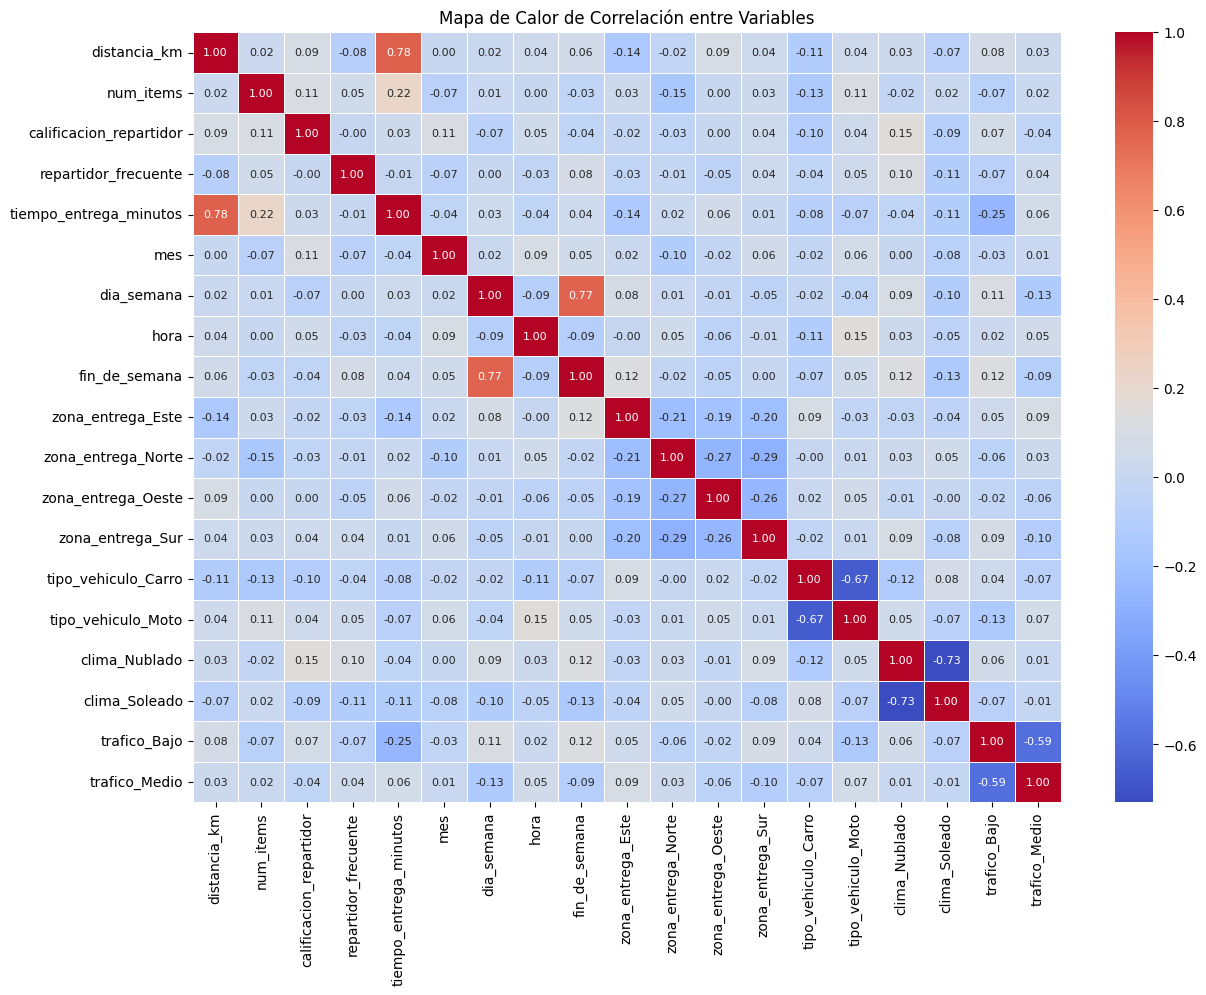

In [17]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={"size": 8})
plt.title('Mapa de Calor de Correlación entre Variables')
plt.show()

**8. Definir las variables predictoras (X) y la variable objetivo (y = tiempo_entrega_minutos), separando en conjunto de entrenamiento y de prueba (80/20).**

8.1 Definición de la variable objetivo (y)

In [18]:
y = df_encoded['tiempo_entrega_minutos']

8.2 Definición de las variables predictores (X) excluyendo la variable objetivo

In [19]:
X = df_encoded.drop(columns=['tiempo_entrega_minutos'])

8.3 Dividir en conjunto de entrenamiento (80%) y prueba (20%)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8.4 Verificación de las dimensiones de los conjuntos

In [21]:
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (208, 18)
Forma de X_test: (52, 18)
Forma de y_train: (208,)
Forma de y_test: (52,)


**9. Entrenar un modelo de regresión (por ejemplo, RandomForestRegressor) con los datos de entrenamiento.**

9.1 Creación de una instancia de Random Forest

In [22]:
modelo = RandomForestRegressor(random_state=42)

9.2 Entrenamos el modelo con los datos anteriores de entrenamiento

In [23]:
modelo.fit(X_train, y_train)

print("Modelo entrenado con exito...")

Modelo entrenado con exito...


**10. Evaluar el modelo con las métricas MAE, RMSE, y R2, comparando el desempeño en entrenamiento contra el de prueba.**

10.1 Hacer predicciones en ambos conjuntos

In [24]:
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

10.2 Calcular métricas para entrenamiento

In [25]:
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

10.3 Cálcular las métricas para prueba

In [26]:
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

10.4 Mostrar los resultados

In [27]:
print("--- Métricas de Evaluación del Modelo ---")
print(f"Entrenamiento -> MAE: {mae_train:.2f} min | RMSE: {rmse_train:.2f} min | R2: {r2_train:.4f}")
print(f"Prueba        -> MAE: {mae_test:.2f} min | RMSE: {rmse_test:.2f} min | R2: {r2_test:.4f}")

--- Métricas de Evaluación del Modelo ---
Entrenamiento -> MAE: 1.50 min | RMSE: 2.05 min | R2: 0.9503
Prueba        -> MAE: 3.87 min | RMSE: 4.94 min | R2: 0.6130


**11. Calcular y graficar la importancia de las variables (feature_importances_) para identificar cuáles influyen más en el tiempo de entrega.**

11.1 Obtener la importancia de las características del modelo entrenado

In [28]:
importancias = modelo.feature_importances_

11.2 Crear un dataframe para visualizarlo

In [29]:
df_importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

11.3 Ordenar de mayor a menor importancia

In [30]:
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

11.4 Gráficar las importancias

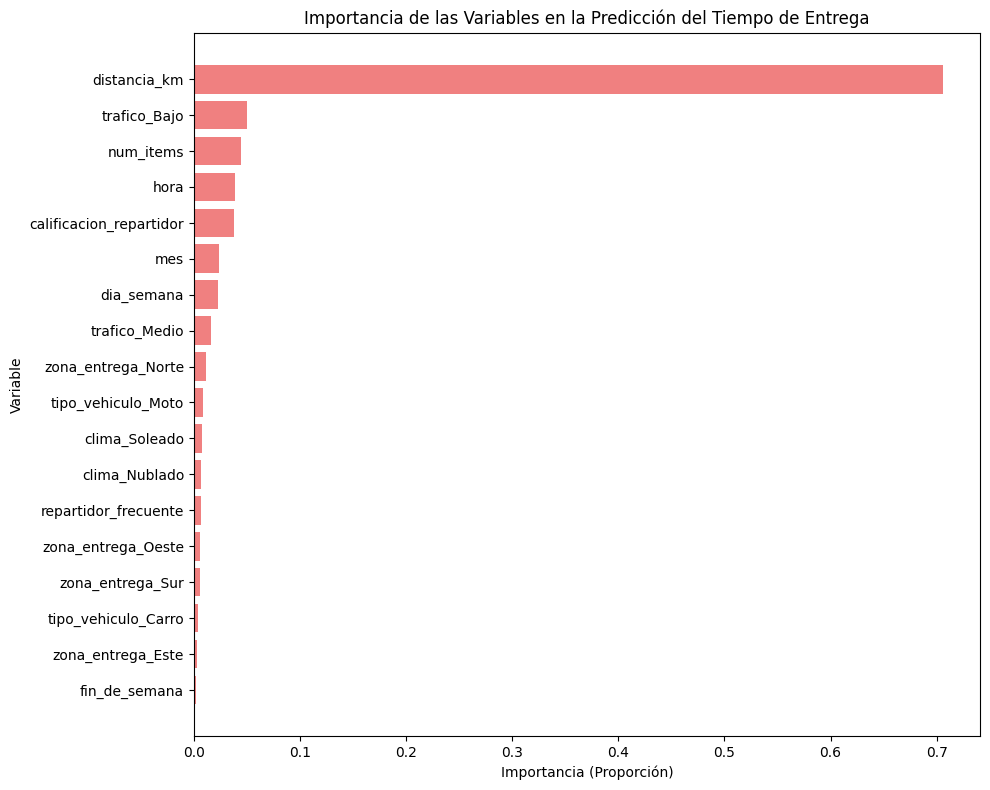

                   Variable  Importancia
0              distancia_km     0.705546
16             trafico_Bajo     0.049820
1                 num_items     0.044841
6                      hora     0.038322
2   calificacion_repartidor     0.037569
4                       mes     0.023813
5                dia_semana     0.022924
17            trafico_Medio     0.016472
9        zona_entrega_Norte     0.011354
13       tipo_vehiculo_Moto     0.008754
15            clima_Soleado     0.007470
14            clima_Nublado     0.006706
3      repartidor_frecuente     0.006418
10       zona_entrega_Oeste     0.006120
11         zona_entrega_Sur     0.005699
12      tipo_vehiculo_Carro     0.003628
8         zona_entrega_Este     0.002487
7             fin_de_semana     0.002055


In [31]:
plt.figure(figsize=(10, 8))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='lightcoral')
plt.gca().invert_yaxis()  # Para que la variable más importante aparezca arriba
plt.title('Importancia de las Variables en la Predicción del Tiempo de Entrega')
plt.xlabel('Importancia (Proporción)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print(df_importancias)

**12.Redactar una breve conclusión con los hallazgos principales (sin incluir interfaz gráfica; basta con imprimir o mostrar una predicción de ejemplo con un registro construido manualmente). **

In [32]:
ejemplo_pedido = {
    'distancia_km': 5.5,
    'num_items': 3,
    'calificacion_repartidor': 4.8,
    'repartidor_frecuente': 1,
    'mes': 10,
    'dia_semana': 5,
    'hora': 20,
    'fin_de_semana': 1,
    'zona_entrega_Este': 0,
    'zona_entrega_Norte': 0,
    'zona_entrega_Oeste': 0,
    'zona_entrega_Sur': 1,
    'tipo_vehiculo_Carro': 1,
    'tipo_vehiculo_Moto': 0,
    'clima_Nublado': 0,
    'clima_Soleado': 1,
    'trafico_Bajo': 0,
    'trafico_Medio': 1
}

ejemplo_df = pd.DataFrame([ejemplo_pedido])
ejemplo_df = ejemplo_df[X.columns]

prediccion_ejemplo = modelo.predict(ejemplo_df)[0]

print("=" * 60)
print("PREDICCIÓN DE EJEMPLO")
print("=" * 60)
print(f"Pedido: {ejemplo_df['distancia_km'].values[0]} km, {ejemplo_df['num_items'].values[0]} items,")
print(f"        Zona Sur, en Carro, Clima Soleado, Tráfico Medio, Sábado a las 20h.")
print(f"Tiempo de entrega predicho por el modelo: {prediccion_ejemplo:.2f} minutos.")
print("=" * 60)

PREDICCIÓN DE EJEMPLO
Pedido: 5.5 km, 3 items,
        Zona Sur, en Carro, Clima Soleado, Tráfico Medio, Sábado a las 20h.
Tiempo de entrega predicho por el modelo: 30.83 minutos.


1. Variables más importantes y lógica de negocio
Las más importantes fueron distancia_km, trafico y num_items. Tiene total sentido, ya que la distancia física, la congestión vial y la carga son los factores que determinan directamente la duración del viaje.
2. Diferencia de R2 y sobreajuste
El R2 cayó de 0.9503 (entrenamiento) a 0.6130 (prueba). Esta gran brecha indica un claro sobreajuste (overfitting): el modelo memorizó los datos de entrenamiento, pero su capacidad para generalizar en datos nuevos es menor.
3. Error promedio del modelo (MAE)
El MAE en prueba fue de 3.87 minutos. En promedio, la predicción del modelo se desvía aproximadamente 4 minutos (por exceso o defecto) del tiempo real.
4. Codificación One-Hot y drop_first
Se codificaron zona_entrega, tipo_vehiculo, clima y trafico usando drop_first=True. Esto evita la multicolinealidad, si se codificaran todas, se crearía una dependencia lineal perfecta que desestabiliza los modelos.
5. Nueva variable a recolectar
El "tiempo de preparación en el restaurante". Separar el tiempo de cocina del tiempo de traslado permitiría un modelo más preciso y accionable para la logística de la empresa.